In [1]:
import numpy as np
import pandas as pd
import random
import os
import sys
import copy
import timeit
import pickle
import uuid
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

import mesa  # ABM framework

In [2]:
from my_batchrunner_patch import patch_batchrunner
patch_batchrunner()

In [3]:
################# import functions from python files
sys.path.append('C:\\Users\\montalci\\Desktop\\AImigration\\G1')
import config #import parameters
from ABM_Agents import BirdsAgent, PoultryAgent #import agents
from ABM_DataCollection import followedagent_info, model_info  #import function used to collect data
from ABM_Model import MigrationandVirus

In [4]:
################# import parameters from configuration file
runname = config.runname
print(runname)
path_save_networkspace = config.path_save_networkspace
print(path_save_networkspace)
path_save_data = config.path_save_data
#path_save_networkspace = r'D:\\G1\\outputAnalysis\\NetworkSpace7March'

#df_network = pd.read_csv(os.path.join(path_save_networkspace,'SUMMARY_NETWORK.csv'), sep=';')
dico_MDOS_GID = pickle.load(open(os.path.join(path_save_networkspace,'dico_MDOS_GID.pkl'), 'rb'))

RandomSamplingHPAIprimed
C:\Users\camil\OneDrive\Desktop\G1\outputAnalysis\NetworkSpace\NetworkSpaceJuly


# Test some parameter-related stuff

approx mean: 20.0375847650042
approx mean: 29.99892438780175


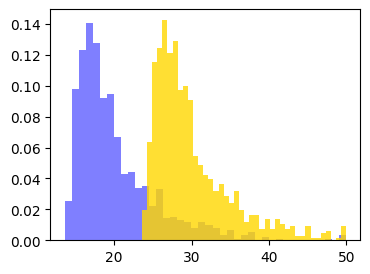

In [5]:
#figure s9
from scipy.stats import exponnorm
# draw and (optionally) clip to your bounds
#generates random variates from an exponentially modified normal distribution. It takes parameters K, loc, and scale, where 
#K controls the shape of the distribution. It's related to the exponential component of the distribution. 
#loc shifts the distribution along the x-axis (location parameter). The default value is 0
# scale: scales the distribution (scale parameter), the default value is 1. 
li_samples = exponnorm.rvs(5, loc=15, scale=1, size=1000, random_state=0)
# clamp values to [0, 150]
li_samples = np.clip(li_samples, 0, 50)
print("approx mean:", np.mean(li_samples))
plt.figure(figsize=(4,3))
plt.hist(li_samples, bins=40, density=True, color='blue', alpha=0.5)

li_samples = exponnorm.rvs(5, loc=25, scale=1, size=1000, random_state=0)
# clamp values to [0, 150]
li_samples = np.clip(li_samples, 0, 50)
print("approx mean:", np.mean(li_samples))
plt.hist(li_samples, bins=40, density=True, color='gold', alpha=0.8)
plt.show()
#if beow 0 redo, to avoid a peak at 0
#300 to represent birds that did not initiate migration within 50 days.

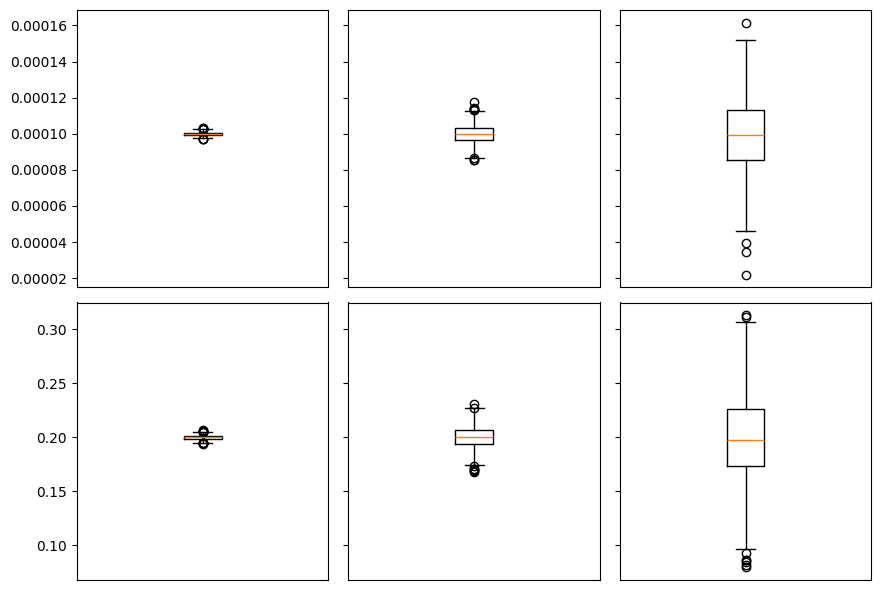

In [6]:
######## check individual heterogeneity in contribution to virus spread
fig, axes = plt.subplots(2, 3, figsize=(9, 6), sharey='row')  # share y-axis by row

data = [np.random.normal(0.0001, 0.0001*(1/100), 1000), 
        np.random.normal(0.0001, 0.0001*(1/20), 1000), 
        np.random.normal(0.0001, 0.0001*(1/5), 1000),
        np.random.normal(0.2, 0.2*(1/100), 1000), 
        np.random.normal(0.2, 0.2*(1/20), 1000), 
        np.random.normal(0.2, 0.2*(1/5), 1000)]

for ax, d in zip(axes.flat, data):
    ax.boxplot(d)
    ax.set_xticks([])  # Remove x-axis ticks

plt.tight_layout()
plt.show()

In [7]:
########### check to what extent the tranmsission rate and shedding rate are correlated
nbr_paramcomb = 10000  # example

def correlated_uniform(base, target_min, target_max, noise_strength=0.8, direction='positive'):
    """
    Generate values correlated (positively or negatively) with a base vector, 
    mapped to a uniform distribution within a specified range.
    Parameters:
    - base: array-like, base values to correlate with
    - target_min, target_max: float, target uniform range
    - noise_strength: float, standard deviation of noise added to base
    - direction: str, 'positive' (default) or 'negative', indicating correlation direction
    Returns:
    - list of values scaled to [target_min, target_max] and correlated with base
    """
    noisy = base + np.random.normal(0, noise_strength, size=len(base))
    if direction == 'negative':
        noisy = -noisy  # invert the relationship
    normed = (noisy - noisy.min()) / (noisy.max() - noisy.min())
    return list(normed * (target_max - target_min) + target_min)
#Base normal variable for correlation
base = np.random.normal(0, 1, nbr_paramcomb)
param_grid = {
    'shedding_rate': correlated_uniform(base, 100, 1000000),
    'deadbirdscalingshedding': correlated_uniform(base, 0.3, 0.5),
    'beta_flbf': correlated_uniform(base, 0.0001, 0.01),
    'beta_ebf': correlated_uniform(base, 0.001, 0.1),
    'beta_vf': correlated_uniform(base, 0.0000001, 0.00001),
    'beta_ff': correlated_uniform(base, 0.001, 0.1),
    'beta_bb': correlated_uniform(base, 0.05, 0.30),
    'beta_eb': correlated_uniform(base, 0.000000001, 0.0000001),
    'beta_fb': correlated_uniform(base, 0.01, 0.15),
    'days_exposed': [max(1, min(8, int(i))) for i in correlated_uniform(base, 1, 8, direction='negative')]}
        
df = pd.DataFrame(param_grid)

######### Compute correlation matrix (Pearson)
corr_matrix = df.corr()
# Extract only the lower triangle (excluding the diagonal) to avoid duplicates and 1s
# Compute summary statistics
min_corr = corr_matrix.stack().min()
display(corr_matrix)
print("Min correlation:", min_corr)

########### describe values
display(df.describe())

,shedding_rate,deadbirdscalingshedding,beta_flbf,beta_ebf,beta_vf,beta_ff,beta_bb,beta_eb,beta_fb,days_exposed
shedding_rate,1.000000,0.597345,0.614806,0.601619,0.610142,0.606349,0.614552,0.599492,0.605908,-0.590070
deadbirdscalingshedding,0.597345,1.000000,0.608086,0.610564,0.604270,0.598154,0.599870,0.607876,0.603582,-0.583931
beta_flbf,0.614806,0.608086,1.000000,0.608718,0.617643,0.609517,0.608236,0.614265,0.611656,-0.587752
beta_ebf,0.601619,0.610564,0.608718,1.000000,0.611085,0.608475,0.608168,0.614864,0.609338,-0.589229
beta_vf,0.610142,0.604270,0.617643,0.611085,1.000000,0.607648,0.611009,0.617124,0.608609,-0.593684
beta_ff,0.606349,0.598154,0.609517,0.608475,0.607648,1.000000,0.610755,0.606296,0.599891,-0.587141
beta_bb,0.614552,0.599870,0.608236,0.608168,0.611009,0.610755,1.000000,0.612971,0.610314,-0.588568
beta_eb,0.599492,0.607876,0.614265,0.614864,0.617124,0.606296,0.612971,1.000000,0.610729,-0.584404
beta_fb,0.605908,0.603582,0.611656,0.609338,0.608609,0.599891,0.610314,0.610729,1.000000,-0.583360
days_exposed,-0.590070,-0.583931,-0.587752,-0.589229,-0.593684,-0.587141,-0.588568,-0.584404,-0.583360,1.000000


Min correlation: -0.5936841800543985


,shedding_rate,deadbirdscalingshedding,beta_flbf,beta_ebf,beta_vf,beta_ff,beta_bb,beta_eb,beta_fb,days_exposed
count,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000
mean,542432.279204,0.399090,0.005153,0.053129,4.999742e-06,0.049594,0.181885,4.910912e-08,0.082412,4.151400
std,126365.329451,0.025975,0.001224,0.012888,1.347348e-06,0.013246,0.033899,1.259386e-08,0.018347,0.932397
min,100.000000,0.300000,0.000100,0.001000,1.000000e-07,0.001000,0.050000,1.000000e-09,0.010000,1.000000
25%,457995.807068,0.381879,0.004318,0.044350,4.105550e-06,0.040670,0.159104,4.068992e-08,0.070195,4.000000
50%,542134.942625,0.398897,0.005147,0.052980,4.997131e-06,0.049729,0.181659,4.905422e-08,0.082518,4.000000
75%,627881.237995,0.416283,0.005992,0.062105,5.905352e-06,0.058465,0.204797,5.747290e-08,0.094781,5.000000
max,1000000.000000,0.500000,0.010000,0.100000,1.000000e-05,0.100000,0.300000,1.000000e-07,0.150000,8.000000


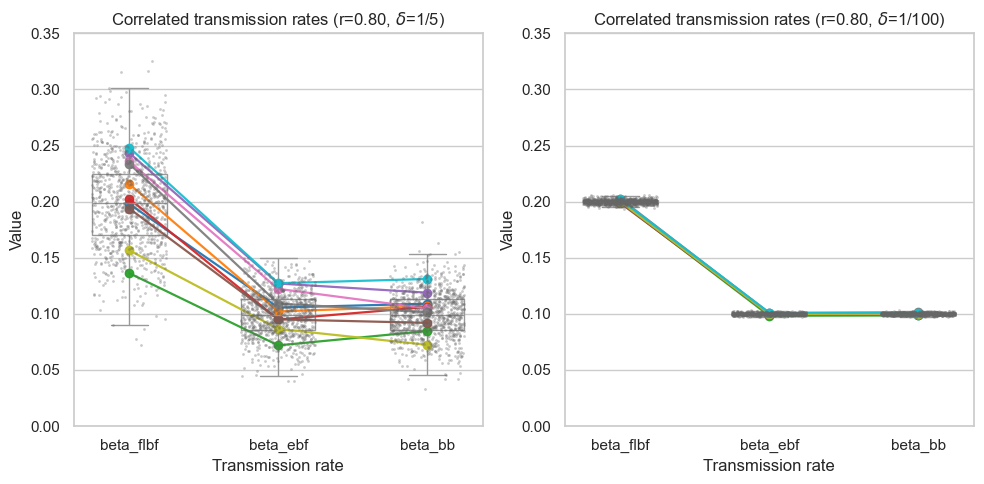

In [8]:
#Figure S3

# Common settings
means = [0.2, 0.1, 0.1]
rho = 0.8
n = 1000
highlight_ids = np.random.choice(n, size=10, replace=False)
palette = sns.color_palette("tab10", 10)

def sample_and_plot(ax, scale_factor):
    stds = [m * scale_factor for m in means]
    corr_matrix = np.array([[1.0, rho, rho], 
                            [rho, 1.0, rho], 
                            [rho, rho, 1.0]])
    cov_matrix = np.outer(stds, stds) * corr_matrix
    df = pd.DataFrame(np.random.multivariate_normal(means, cov_matrix, size=n), columns=["beta_flbf", "beta_ebf", "beta_bb"])
    df["id"] = np.arange(n)
    df_melt = df.melt(id_vars="id", var_name="type", value_name="value")
    sns.boxplot(x="type", y="value", data=df_melt, ax=ax, color="white", width=0.5, fliersize=0)
    sns.stripplot(x="type", y="value", data=df_melt, ax=ax, color="0.4", size=2, jitter=0.25, alpha=0.35)
    for j, sid in enumerate(highlight_ids):
        yvals = df.loc[sid, ["beta_flbf", "beta_ebf", "beta_bb"]].values
        ax.plot([0, 1, 2], yvals, color=palette[j], marker="o", markersize=6, linewidth=1.6, alpha=0.95)
    ax.set_xlabel("Transmission rate"); ax.set_ylabel("Value"); ax.set_ylim(0,0.35)
    ax.set_title("Correlated transmission rates (r=%.2f, $\delta$=1/%d)" % (rho, int(1/scale_factor)))

sns.set(style="whitegrid")
fig, axes = plt.subplots(1,2, figsize=(10,5))
sample_and_plot(axes[0], 1/5)
sample_and_plot(axes[1], 1/100)
plt.tight_layout(); plt.show()

# Run the model

ATTENTION the parameter space should be done so that bird cant get new symptoms while the other one have not been finished.

In [9]:
#HPAI Naive
print('lets start running the model!')
start_time = timeit.default_timer() #register how long it is running for

#has to be within this code block, otherwise files associated 'run0' will override the old files associated with 'run0'
unique_run_id = str(uuid.uuid4())  # Example: '3fa85f64-5717-4562-b3fc-2c963f66afa6'
print(unique_run_id)

#Define the number of random runs
nbr_paramcomb = 2000 
N = 3000
debuging = False
runnameparam = 'N'+str(N)+ '_debuging'+str(debuging)
print('RUNNAME IS: %s'%runname)
print('RUNNAMEPARAM IS: %s'%runnameparam)

path_save = os.path.join(config.path_save_data, runnameparam, 'allbatches',unique_run_id)
os.makedirs(path_save, exist_ok=True)  # Creates directory only if it doesn't exist

    
#During debugging we will only use one MDOS and one graph (while ensuring remainingdsitance2node can be >0)
if debuging:
    li_MDOS = [6 for _ in range(nbr_paramcomb)] #includes 4- 20
    #li_MDOS = [random.randint(5,15) for _ in range(nbr_paramcomb)]
    li_GID = [dico_MDOS_GID[i][0] for i in li_MDOS]
    if len(set(li_GID))!=1:
        print('ERROR: FOR NOW LETS TAKE ONLY ONE GRAPH')
        sys.exit()
    with open(os.path.join(config.path_save_networkspace, li_GID[0]+ '_graph.pkl'), 'rb') as f:
        G = pickle.load(f)
        #assuming all edge have the same attribute, we jsut look at the first edge attribute
        print('\nEDGES ATTRIBUTES: \n%s\n'%', \n'.join(list(list(G.edges(data=True))[0][-1].keys())))
        #assuming all nodes have the same attribute, we jsut look at the first node attribute
        print('NODES ATTRIBUTES: \n%s\n'%', \n'.join(list(list(G.nodes(data=True))[0][-1].keys())))

    print('CHECKING if birds have to fly in several days, important for debugging stage:')
    min_distances = [data["min_distance2patch"]*10**3 for u,v, data in G.edges(data=True) if "min_distance2patch" in data]
    plt.figure(figsize=(3,2))
    plt.boxplot(min_distances)
    f = np.mean(min_distances)/86.4
    plt.title('max km/day in flight: '+str(f)+'(m/s)')
    plt.show()
    li_f = [random.uniform(f-2, f+2) for _ in range(nbr_paramcomb)]
else: 
    #select random values for MDOS, and choose graphID accordingly
    li_MDOS = [random.randint(4,20) for _ in range(nbr_paramcomb)] #includes 4- 20
    li_GID = []
    for mdos in li_MDOS:
        li_GID.append(random.choice(dico_MDOS_GID[mdos]))
    li_f =  [random.uniform(15, 23) for _ in range(nbr_paramcomb)]

#body mass
li_body_mass_mean = [random.uniform(0.3, 10) for _ in range(nbr_paramcomb)]
li_body_mass_sd = [i*0.05 for i in li_body_mass_mean]

#base_transmission_rate parameter
base = np.random.normal(0, 1, nbr_paramcomb)# Base normal variable for correlation: keep track of the base as well

# Generate random parameter sets
li_acc_body_mass_migration_threshold = [random.uniform(0.12, 0.175) for _ in range(nbr_paramcomb)]
params = {'N': [N] * nbr_paramcomb,
          
        'base_transmission_rate': list(base), # Base normal variable for correlation: keep track of the base as well
        'days_resistant': [300] * nbr_paramcomb,#[random.randint(28, 300) for _ in range(nbr_paramcomb)],
        'days_exposed': [max(1, min(3, int(i))) for i in correlated_uniform(base, 1, 3, direction='negative')], 
        'days_incubation': [random.randint(2, 5) for _ in range(nbr_paramcomb)],
        'days_symptom': [random.randint(4,10) for _ in range(nbr_paramcomb)],
        'days_infected': [random.randint(4,10) for _ in range(nbr_paramcomb)],

        'beta_bb_mean': correlated_uniform(base, 0.01, 0.20), #was up to 0.15
        'beta_ebf_mean': correlated_uniform(base, 0.001, 0.2),
        'beta_flbf_mean': correlated_uniform(base, 0.0001, 0.01), #TODO next time 0.00001, 0.001

        'beta_eb': correlated_uniform(base, 0.00000000001, 0.0000000002),# 0.00000000001*50 is 0.0000000005 
        'beta_fb': correlated_uniform(base, 0.01, 0.30),         
        'beta_vf': correlated_uniform(base, 0.0000001, 0.000001),#was up to 0.000005
        'beta_ff': correlated_uniform(base, 0.001, 0.1),
          
        'shedding_rate': correlated_uniform(base, 20000, 7000000),#[random.uniform(0.05, 0.15) for _ in range(nbr_paramcomb)],
        'deadbirdscalingshedding': correlated_uniform(base, 0.05, 0.1),# was 0.3-0.5. 0.5: effect of dead birds last at max 10 days, 0.3: effect last at max 15 days
        'p_it': [random.uniform(0, 0.0005) for _ in range(nbr_paramcomb)], #TODO next time: put HIGHER
        'initial_outbreak_proportion': [random.uniform(0.005, 0.01) for _ in range(nbr_paramcomb)],#4debugging: [0.2] * nbr_paramcomb,#
        'excess_TR_naive': [random.uniform(1.2, 2) for _ in range(nbr_paramcomb)],#beta_ebf, beta_bb, or beta_flbf = self.beta_flbf*self.excess_TR_naive if age_cat=='naive' else self.beta_flbf
        'excess_CO_naive': [random.uniform(1.2, 2) for _ in range(nbr_paramcomb)],#excess_CO = self.excess_CO_naive if is_naive==1 else 1; e.g., p_r_virusenv = p_x_t*P_x*(beta_eb*self.model.excess_CO_naive*is_naive)*virusinenv/surface_site
        'excess_SH_naive': [random.uniform(1.2, 2) for _ in range(nbr_paramcomb)],#shedding_rate = self.shedding_rate*self.excess_SH_naive if age_cat=='naive' else self.shedding_rate
  
        'proba_dying': correlated_uniform(base, 0.01, 0.1),
        'proba_dying_scalenaive': [random.uniform(2, 6) for _ in range(nbr_paramcomb)], 
        'delayedmigrationinfectedLOC': [random.randint(15, 25) for _ in range(nbr_paramcomb)],#debug: [30] * nbr_paramcomb,#
        'delayedmigrationinfectedLOC_scalenaive': [random.uniform(1.2, 1.8) for _ in range(nbr_paramcomb)], #for naive birs: psi = psi*self.scaled_delayedmigrationinfected4naive
        'omega': [random.uniform(0.1,0.3) for _ in range(nbr_paramcomb)],
        'omega_scalenaive': [random.uniform(1.2,1.8) for _ in range(nbr_paramcomb)],
        'generalproptimeresting_I': [random.uniform(1.2, 1.4) for _ in range(nbr_paramcomb)],#was up to 1.4. infected bird will have: self.generalproptimeresting = self.generalproptimeresting*self.model.generalproptimeresting_I
        'generalproptimeresting_I_scalenaive': [random.uniform(1.2, 1.8) for _ in range(nbr_paramcomb)],#was up to 1.4. infected bird will have: self.generalproptimeresting = self.generalproptimeresting*self.model.generalproptimeresting_I
        'home_range_area_I': [random.uniform(0.5, 0.8) for _ in range(nbr_paramcomb)],#infected bird will have: self.home_range_area = self.home_range_area*self.model.home_range_area_I
        'home_range_area_I_scalenaive': [random.uniform(0.3, 0.5) for _ in range(nbr_paramcomb)],#infected bird will have: self.home_range_area = self.home_range_area*self.model.home_range_area_I
        'SYM': correlated_uniform(base, 0.05, 0.75),#[random.uniform(0, 1) for _ in range(nbr_paramcomb)],

        'watertemperature':[random.uniform(0, 25) for _ in range(nbr_paramcomb)],
        'pH':[round(random.uniform(5, 8.5),1) for _ in range(nbr_paramcomb)],
        'alpha_T': [random.uniform(0.00293, 0.00523) for _ in range(nbr_paramcomb)],
        'gamma_T': [random.uniform(0.114, 0.142) for _ in range(nbr_paramcomb)],
        'alpha_pH': [random.uniform(0.9, 1.13) for _ in range(nbr_paramcomb)],
        'gamma_pH': [random.uniform(7.5, 7.8) for _ in range(nbr_paramcomb)],           
          
        #check water connectivty in notebook 1 when creating networks
        'ck':[round(random.uniform(0.0001, 0.03),5) for _ in range(nbr_paramcomb)], #called c in the supp. but easier to search for if called ck in the code

        'temporal_synchrony': [round(random.uniform(0.5, 3),1) for _ in range(nbr_paramcomb)], #was 0.5-50
        'proba_startmigration': [random.uniform(0.4, 0.9) for _ in range(nbr_paramcomb)],# OK???? was 0.8-1
        'spatial_synchrony': [random.uniform(0.7, 1) for _ in range(nbr_paramcomb)],
        'tradeoff_mean': [random.uniform(0.7, 1) for _ in range(nbr_paramcomb)],#is = T here: dico_neighbournodeID_O[n]*T*(1 if A>0 else 0) + A*(1-T)
        'tradeoff_sd': [0] * nbr_paramcomb,#note: the mean will be ensured between 0-1

        'expected_MDOS': li_MDOS,
        'generalproptimeresting_mean': [random.uniform(0.2, 0.8) for _ in range(nbr_paramcomb)],
        'generalproptimeresting_sd': [0] * nbr_paramcomb,#was 0.05. note that the mean will be forced to be taking values within 0-1 in the model
        'beta_bird_sd':[random.uniform(1/100,1/5) for _ in range(nbr_paramcomb)], #delta, dispersion parameter

        'prop_naive': [random.uniform(0.8,0.95) for _ in range(nbr_paramcomb)], #primed: [random.uniform(0.05,0.2) for _ in range(nbr_paramcomb)], 
        'initial_immune_proportion': [random.uniform(0, 0.05) for _ in range(nbr_paramcomb)], #primed: [random.uniform(0.5, 0.75) for _ in range(nbr_paramcomb)],
        'body_mass_mean': li_body_mass_mean, #in kg
        'body_mass_sd': li_body_mass_sd, #in kg
        'theta': [0.7] * nbr_paramcomb, #proportion of initial body mass that corresponds to the bird lean mass
        'f_ms': li_f,#in m/s. we will mulitply by 86.4 to get it in km/day in the model

        'lambda0chicken': [0.3] * nbr_paramcomb,
        'lambda0duck': [0.05] * nbr_paramcomb,
        'xi_probadetectfarm': [random.uniform(0.1,0.3) for _ in range(nbr_paramcomb)], #surveillance
        'sanitation': [random.uniform(1,1.5) for _ in range(nbr_paramcomb)], #mutliply with transmission rate
          
        'birddensity_scaling': [0.05] * nbr_paramcomb,
        'checkice': [False] * nbr_paramcomb,#only to control for ice phenology in spring migration but not in autumn migration (when set to True; here set to false since we are no longer using juvenile as a parameter and thus spring vs autumn migration are longer differentiable)
        'printdebug': [False] * nbr_paramcomb,
        'debuging': [debuging] * nbr_paramcomb,
        'GID': li_GID,
        'nbr_birds2follow': [N] * nbr_paramcomb,
        'DOY': [90] * nbr_paramcomb, #only used to control ice phenology, so as we dont use it, lets just set it to . else: [80 if i==0 else 230 for i in li_propjuvenile] & li_propjuvenile = [0 if random.random() < 0.2 else random.uniform(0.20, 0.30) for _ in range(nbr_paramcomb)]
        'water_volume_sites': [50] * nbr_paramcomb #in km3
        }

# Save as a list since dict_keys is not serializable by default, saving it in the runname folder, becasue they hsould all have 
# under the same model.
with open(os.path.join(path_save_data , 'param_keys.pkl'), 'wb') as f:
    pickle.dump(list(params.keys()), f)

mesa.batchrunner.batch_run(MigrationandVirus,
                           parameters=params,
                           iterations=1,#The number of iterations to run each parameter-combination for. 
                           max_steps=150,#The maximum number of time steps after which the model halts. An episode does either end when self.running of the model class is set to False or when model.schedule.steps == max_steps is reached. Optional. If not specified, defaults to 1000.
                           data_collection_period=1,#The length of the period (number of steps) after which the model and agent reporters collect data.  If not specified, defaults to -1, i.e. only at the end of each episode.
                           display_progress=True, 
                           path_save=path_save,
                           number_processes=os.cpu_count()-10)#os.cpu_count()-1) #no more print when its in parallel, so for debigging dont use parallel
    
#we run the model one time per iteration * #combination
elapsed = timeit.default_timer() - start_time
print("Elapsed time: %.2f minutes" % (elapsed / 60)) 

lets start running the model!
c2e118b0-397b-4b93-b962-250961671647
RUNNAME IS: RandomSamplingHPAI
RUNNAMEPARAM IS: N3000_debugingFalse


  0%|          | 0/2000 [00:00<?, ?it/s]

Elapsed time: 1229.59 minutes


In [10]:
#with open(os.path.join(path_save_data , 'param_keys.pkl'), 'rb') as f: 
#    loaded_keys = pickle.load(f)
#print(loaded_keys)
params.keys() #to copy paste in the notebook "4_SimulatedDataAnalysis_IMPORTANCE"

dict_keys(['N', 'base_transmission_rate', 'days_resistant', 'days_exposed', 'days_incubation', 'days_symptom', 'days_infected', 'beta_bb_mean', 'beta_ebf_mean', 'beta_flbf_mean', 'beta_eb', 'beta_fb', 'beta_vf', 'beta_ff', 'shedding_rate', 'deadbirdscalingshedding', 'p_it', 'initial_outbreak_proportion', 'proba_dying', 'proba_dying_scalenaive', 'delayedmigrationinfectedLOC', 'delayedmigrationinfectedLOC_scalenaive', 'omega', 'omega_scalenaive', 'generalproptimeresting_I', 'generalproptimeresting_I_scalenaive', 'home_range_area_I', 'home_range_area_I_scalenaive', 'SYM', 'excess_TR_naive', 'excess_CO_naive', 'excess_SH_naive', 'watertemperature', 'pH', 'alpha_T', 'gamma_T', 'alpha_pH', 'gamma_pH', 'ck', 'temporal_synchrony', 'proba_startmigration', 'spatial_synchrony', 'tradeoff_mean', 'tradeoff_sd', 'expected_MDOS', 'generalproptimeresting_mean', 'generalproptimeresting_sd', 'beta_bird_sd', 'prop_naive', 'initial_immune_proportion', 'body_mass_mean', 'body_mass_sd', 'theta', 'f_ms', 'la

In [10]:
#HPAI Primed
print('lets start running the model!')
start_time = timeit.default_timer() #register how long it is running for

#has to be within this code block, otherwise files associated 'run0' will override the old files associated with 'run0'
unique_run_id = str(uuid.uuid4())  # Example: '3fa85f64-5717-4562-b3fc-2c963f66afa6'
print(unique_run_id)

#Define the number of random runs
nbr_paramcomb = 2000 
N = 3000
debuging = False
runnameparam = 'N'+str(N)+ '_debuging'+str(debuging)
print('RUNNAME IS: %s'%runname)
print('RUNNAMEPARAM IS: %s'%runnameparam)

path_save = os.path.join(config.path_save_data, runnameparam, 'allbatches',unique_run_id)
os.makedirs(path_save, exist_ok=True)  # Creates directory only if it doesn't exist

    
#During debugging we will only use one MDOS and one graph (while ensuring remainingdsitance2node can be >0)
if debuging:
    li_MDOS = [6 for _ in range(nbr_paramcomb)] #includes 4- 20
    #li_MDOS = [random.randint(5,15) for _ in range(nbr_paramcomb)]
    li_GID = [dico_MDOS_GID[i][0] for i in li_MDOS]
    if len(set(li_GID))!=1:
        print('ERROR: FOR NOW LETS TAKE ONLY ONE GRAPH')
        sys.exit()
    with open(os.path.join(config.path_save_networkspace, li_GID[0]+ '_graph.pkl'), 'rb') as f:
        G = pickle.load(f)
        #assuming all edge have the same attribute, we jsut look at the first edge attribute
        print('\nEDGES ATTRIBUTES: \n%s\n'%', \n'.join(list(list(G.edges(data=True))[0][-1].keys())))
        #assuming all nodes have the same attribute, we jsut look at the first node attribute
        print('NODES ATTRIBUTES: \n%s\n'%', \n'.join(list(list(G.nodes(data=True))[0][-1].keys())))

    print('CHECKING if birds have to fly in several days, important for debugging stage:')
    min_distances = [data["min_distance2patch"]*10**3 for u,v, data in G.edges(data=True) if "min_distance2patch" in data]
    plt.figure(figsize=(3,2))
    plt.boxplot(min_distances)
    f = np.mean(min_distances)/86.4
    plt.title('max km/day in flight: '+str(f)+'(m/s)')
    plt.show()
    li_f = [random.uniform(f-2, f+2) for _ in range(nbr_paramcomb)]
else: 
    #select random values for MDOS, and choose graphID accordingly
    li_MDOS = [random.randint(4,20) for _ in range(nbr_paramcomb)] #includes 4- 20
    li_GID = []
    for mdos in li_MDOS:
        li_GID.append(random.choice(dico_MDOS_GID[mdos]))
    li_f =  [random.uniform(15, 23) for _ in range(nbr_paramcomb)]

#body mass
li_body_mass_mean = [random.uniform(0.3, 10) for _ in range(nbr_paramcomb)]
li_body_mass_sd = [i*0.05 for i in li_body_mass_mean]

#base_transmission_rate parameter
base = np.random.normal(0, 1, nbr_paramcomb)# Base normal variable for correlation: keep track of the base as well

# Generate random parameter sets
li_acc_body_mass_migration_threshold = [random.uniform(0.12, 0.175) for _ in range(nbr_paramcomb)]
params = {'N': [N] * nbr_paramcomb,
          
        'base_transmission_rate': list(base), # Base normal variable for correlation: keep track of the base as well
        'days_resistant': [300] * nbr_paramcomb,#[random.randint(28, 300) for _ in range(nbr_paramcomb)],
        'days_exposed': [max(1, min(3, int(i))) for i in correlated_uniform(base, 1, 3, direction='negative')], 
        'days_incubation': [random.randint(2, 5) for _ in range(nbr_paramcomb)],
        'days_symptom': [random.randint(4,10) for _ in range(nbr_paramcomb)],
        'days_infected': [random.randint(4,10) for _ in range(nbr_paramcomb)],

        'beta_bb_mean': correlated_uniform(base, 0.01, 0.20), #was up to 0.15
        'beta_ebf_mean': correlated_uniform(base, 0.001, 0.2),
        'beta_flbf_mean': correlated_uniform(base, 0.0001, 0.01), #TODO next time 0.00001, 0.001

        'beta_eb': correlated_uniform(base, 0.00000000001, 0.0000000002),# 0.00000000001*50 is 0.0000000005 
        'beta_fb': correlated_uniform(base, 0.01, 0.30),         
        'beta_vf': correlated_uniform(base, 0.0000001, 0.000001),#was up to 0.000005
        'beta_ff': correlated_uniform(base, 0.001, 0.1),
          
        'shedding_rate': correlated_uniform(base, 20000, 7000000),#[random.uniform(0.05, 0.15) for _ in range(nbr_paramcomb)],
        'deadbirdscalingshedding': correlated_uniform(base, 0.05, 0.1),# was 0.3-0.5. 0.5: effect of dead birds last at max 10 days, 0.3: effect last at max 15 days
        'p_it': [random.uniform(0, 0.0005) for _ in range(nbr_paramcomb)], #TODO next time: put HIGHER
        'initial_outbreak_proportion': [random.uniform(0.005, 0.01) for _ in range(nbr_paramcomb)],#4debugging: [0.2] * nbr_paramcomb,#

        'proba_dying': correlated_uniform(base, 0.01, 0.1),
        'proba_dying_scalenaive': [random.uniform(2, 6) for _ in range(nbr_paramcomb)], 
        'delayedmigrationinfectedLOC': [random.randint(15, 25) for _ in range(nbr_paramcomb)],#debug: [30] * nbr_paramcomb,#
        'delayedmigrationinfectedLOC_scalenaive': [random.uniform(1.2, 1.8) for _ in range(nbr_paramcomb)], #for naive birs: psi = psi*self.scaled_delayedmigrationinfected4naive
        'omega': [random.uniform(0.1,0.3) for _ in range(nbr_paramcomb)],
        'omega_scalenaive': [random.uniform(1.2,1.8) for _ in range(nbr_paramcomb)],
        'generalproptimeresting_I': [random.uniform(1.2, 1.4) for _ in range(nbr_paramcomb)],#was up to 1.4. infected bird will have: self.generalproptimeresting = self.generalproptimeresting*self.model.generalproptimeresting_I
        'generalproptimeresting_I_scalenaive': [random.uniform(1.2, 1.8) for _ in range(nbr_paramcomb)],#was up to 1.4. infected bird will have: self.generalproptimeresting = self.generalproptimeresting*self.model.generalproptimeresting_I
        'home_range_area_I': [random.uniform(0.5, 0.8) for _ in range(nbr_paramcomb)],#infected bird will have: self.home_range_area = self.home_range_area*self.model.home_range_area_I
        'home_range_area_I_scalenaive': [random.uniform(0.3, 0.5) for _ in range(nbr_paramcomb)],#infected bird will have: self.home_range_area = self.home_range_area*self.model.home_range_area_I
        'SYM': correlated_uniform(base, 0.05, 0.75),#[random.uniform(0, 1) for _ in range(nbr_paramcomb)],
        'excess_TR_naive': [random.uniform(1.2, 2) for _ in range(nbr_paramcomb)],#beta_ebf, beta_bb, or beta_flbf = self.beta_flbf*self.excess_TR_naive if age_cat=='naive' else self.beta_flbf
        'excess_CO_naive': [random.uniform(1.2, 2) for _ in range(nbr_paramcomb)],#excess_CO = self.excess_CO_naive if is_naive==1 else 1; e.g., p_r_virusenv = p_x_t*P_x*(beta_eb*self.model.excess_CO_naive*is_naive)*virusinenv/surface_site
        'excess_SH_naive': [random.uniform(1.2, 2) for _ in range(nbr_paramcomb)],#shedding_rate = self.shedding_rate*self.excess_SH_naive if age_cat=='naive' else self.shedding_rate
  
        'watertemperature':[random.uniform(0, 25) for _ in range(nbr_paramcomb)],
        'pH':[round(random.uniform(5, 8.5),1) for _ in range(nbr_paramcomb)],
        'alpha_T': [random.uniform(0.00293, 0.00523) for _ in range(nbr_paramcomb)],
        'gamma_T': [random.uniform(0.114, 0.142) for _ in range(nbr_paramcomb)],
        'alpha_pH': [random.uniform(0.9, 1.13) for _ in range(nbr_paramcomb)],
        'gamma_pH': [random.uniform(7.5, 7.8) for _ in range(nbr_paramcomb)],           
          
        #check water connectivty in notebook 1 when creating networks
        'ck':[round(random.uniform(0.0001, 0.03),5) for _ in range(nbr_paramcomb)], #called c in the supp. but easier to search for if called ck in the code

        'temporal_synchrony': [round(random.uniform(0.5, 3),1) for _ in range(nbr_paramcomb)], #was 0.5-50
        'proba_startmigration': [random.uniform(0.4, 0.9) for _ in range(nbr_paramcomb)],# OK???? was 0.8-1
        'spatial_synchrony': [random.uniform(0.7, 1) for _ in range(nbr_paramcomb)],
        'tradeoff_mean': [random.uniform(0.7, 1) for _ in range(nbr_paramcomb)],#is = T here: dico_neighbournodeID_O[n]*T*(1 if A>0 else 0) + A*(1-T)
        'tradeoff_sd': [0] * nbr_paramcomb,#note: the mean will be ensured between 0-1

        'expected_MDOS': li_MDOS,
        'generalproptimeresting_mean': [random.uniform(0.2, 0.8) for _ in range(nbr_paramcomb)],
        'generalproptimeresting_sd': [0] * nbr_paramcomb,#was 0.05. note that the mean will be forced to be taking values within 0-1 in the model
        'beta_bird_sd':[random.uniform(1/100,1/5) for _ in range(nbr_paramcomb)], #delta, dispersion parameter

        'prop_naive': [random.uniform(0.05,0.2) for _ in range(nbr_paramcomb)], #primed: [random.uniform(0.05,0.2) for _ in range(nbr_paramcomb)], 
        'initial_immune_proportion': [random.uniform(0.4, 0.75) for _ in range(nbr_paramcomb)], #primed: [random.uniform(0.5, 0.75) for _ in range(nbr_paramcomb)],
        'body_mass_mean': li_body_mass_mean, #in kg
        'body_mass_sd': li_body_mass_sd, #in kg
        'theta': [0.7] * nbr_paramcomb, #proportion of initial body mass that corresponds to the bird lean mass
        'f_ms': li_f,#in m/s. we will mulitply by 86.4 to get it in km/day in the model

        'lambda0chicken': [0.3] * nbr_paramcomb,
        'lambda0duck': [0.05] * nbr_paramcomb,
        'xi_probadetectfarm': [random.uniform(0.1,0.3) for _ in range(nbr_paramcomb)], #surveillance
        'sanitation': [random.uniform(1,1.5) for _ in range(nbr_paramcomb)], #mutliply with transmission rate
          
        'birddensity_scaling': [0.05] * nbr_paramcomb,
        'checkice': [False] * nbr_paramcomb,#only to control for ice phenology in spring migration but not in autumn migration (when set to True; here set to false since we are no longer using juvenile as a parameter and thus spring vs autumn migration are longer differentiable)
        'printdebug': [False] * nbr_paramcomb,
        'debuging': [debuging] * nbr_paramcomb,
        'GID': li_GID,
        'nbr_birds2follow': [N] * nbr_paramcomb,
        'DOY': [90] * nbr_paramcomb, #only used to control ice phenology, so as we dont use it, lets just set it to . else: [80 if i==0 else 230 for i in li_propjuvenile] & li_propjuvenile = [0 if random.random() < 0.2 else random.uniform(0.20, 0.30) for _ in range(nbr_paramcomb)]
        'water_volume_sites': [50] * nbr_paramcomb #in km3
        }

# Save as a list since dict_keys is not serializable by default, saving it in the runname folder, becasue they hsould all have 
# under the same model.
with open(os.path.join(path_save_data , 'param_keys.pkl'), 'wb') as f:
    pickle.dump(list(params.keys()), f)

mesa.batchrunner.batch_run(MigrationandVirus,
                           parameters=params,
                           iterations=1,#The number of iterations to run each parameter-combination for. 
                           max_steps=150,#The maximum number of time steps after which the model halts. An episode does either end when self.running of the model class is set to False or when model.schedule.steps == max_steps is reached. Optional. If not specified, defaults to 1000.
                           data_collection_period=1,#The length of the period (number of steps) after which the model and agent reporters collect data.  If not specified, defaults to -1, i.e. only at the end of each episode.
                           display_progress=True, 
                           path_save=path_save,
                           number_processes=os.cpu_count()-1)#os.cpu_count()-1) #no more print when its in parallel, so for debigging dont use parallel
    
#we run the model one time per iteration * #combination
elapsed = timeit.default_timer() - start_time
print("Elapsed time: %.2f minutes" % (elapsed / 60)) 

lets start running the model!
c4e9f561-80b5-43b0-9a37-5d55bd4f2948
RUNNAME IS: RandomSamplingHPAIprimed
RUNNAMEPARAM IS: N3000_debugingFalse


  0%|          | 0/2000 [00:00<?, ?it/s]

ValueError: concurrent send_bytes() calls are not supported

In [11]:
#pip uninstall mesa -y

In [12]:
#import mesa
#print(mesa.__version__)

In [13]:
#pip install mesa==2.4.0
#from mesa.time import StagedActivation 

####### TODO as possiible extension, include several population. 
#with a single population
params_ = {"a": [1, 88], "b": [11, 2], "c": [9, 7]}
x = [{k: v[i] for k, v in params_ .items()} for i in range(2)]
x

#with 1 or more population populations
li_params = [{"a": [6, 8],  "b": [8, 3],  "c": [7, 0]}]
li_params = [{"a": [1, 88], "b": [11, 2], "c": [9, 7]},
             {"a": [6, 8],  "b": [8, 3],  "c": [7, 0]}]
li_params = [{"a": [1, 88], "b": [11, 2], "c": [9, 7]},
             {"a": [6, 8],  "b": [8, 3],  "c": [7, 0]},
             {"a": [26, 28],  "b": [28, 23],  "c": [27, 20]}]
nbr_paramcomb = len(li_params[0]["a"])  # assuming all lists have same length
x = [{k: tuple(p[k][i] for p in li_params) for k in li_params[0].keys()} for i in range(2)]
x

In [11]:
#LPAI primed birds
print('lets start running the model!')
start_time = timeit.default_timer() #register how long it is running for

#has to be within this code block, otherwise files associated 'run0' will override the old files associated with 'run0'
unique_run_id = str(uuid.uuid4())  # Example: '3fa85f64-5717-4562-b3fc-2c963f66afa6'
print(unique_run_id)

#Define the number of random runs
nbr_paramcomb = 2000 
N = 3000
debuging = False
runnameparam = 'N'+str(N)+ '_debuging'+str(debuging)
print('RUNNAME IS: %s'%runname)
print('RUNNAMEPARAM IS: %s'%runnameparam)

path_save = os.path.join(config.path_save_data, runnameparam, 'allbatches',unique_run_id)
os.makedirs(path_save, exist_ok=True)  # Creates directory only if it doesn't exist

    
#During debugging we will only use one MDOS and one graph (while ensuring remainingdsitance2node can be >0)
if debuging:
    li_MDOS = [6 for _ in range(nbr_paramcomb)] #includes 4- 20
    #li_MDOS = [random.randint(5,15) for _ in range(nbr_paramcomb)]
    li_GID = [dico_MDOS_GID[i][0] for i in li_MDOS]
    if len(set(li_GID))!=1:
        print('ERROR: FOR NOW LETS TAKE ONLY ONE GRAPH')
        sys.exit()
    with open(os.path.join(config.path_save_networkspace, li_GID[0]+ '_graph.pkl'), 'rb') as f:
        G = pickle.load(f)
        #assuming all edge have the same attribute, we jsut look at the first edge attribute
        print('\nEDGES ATTRIBUTES: \n%s\n'%', \n'.join(list(list(G.edges(data=True))[0][-1].keys())))
        #assuming all nodes have the same attribute, we jsut look at the first node attribute
        print('NODES ATTRIBUTES: \n%s\n'%', \n'.join(list(list(G.nodes(data=True))[0][-1].keys())))

    print('CHECKING if birds have to fly in several days, important for debugging stage:')
    min_distances = [data["min_distance2patch"]*10**3 for u,v, data in G.edges(data=True) if "min_distance2patch" in data]
    plt.figure(figsize=(3,2))
    plt.boxplot(min_distances)
    f = np.mean(min_distances)/86.4
    plt.title('max km/day in flight: '+str(f)+'(m/s)')
    plt.show()
    li_f = [random.uniform(f-2, f+2) for _ in range(nbr_paramcomb)]
else: 
    #select random values for MDOS, and choose graphID accordingly
    li_MDOS = [random.randint(4,20) for _ in range(nbr_paramcomb)] #includes 4- 20
    li_GID = []
    for mdos in li_MDOS:
        li_GID.append(random.choice(dico_MDOS_GID[mdos]))
    li_f =  [random.uniform(15, 23) for _ in range(nbr_paramcomb)]

#body mass
li_body_mass_mean = [random.uniform(0.3, 10) for _ in range(nbr_paramcomb)]
li_body_mass_sd = [i*0.05 for i in li_body_mass_mean]

#base_transmission_rate parameter
base = np.random.normal(0, 1, nbr_paramcomb)# Base normal variable for correlation: keep track of the base as well

# Generate random parameter sets
li_acc_body_mass_migration_threshold = [random.uniform(0.12, 0.175) for _ in range(nbr_paramcomb)]
params = {'N': [N] * nbr_paramcomb,
          
        'base_transmission_rate': list(base), # Base normal variable for correlation: keep track of the base as well
        'days_resistant': [random.randint(28, 300) for _ in range(nbr_paramcomb)],#[random.randint(28, 300) for _ in range(nbr_paramcomb)],
        'days_exposed': [max(1, min(8, int(i))) for i in correlated_uniform(base, 1, 8, direction='negative')], 
        'days_incubation': [random.randint(1, 1) for _ in range(nbr_paramcomb)],
        'days_symptom': [random.randint(1,1) for _ in range(nbr_paramcomb)],
        'days_infected': [random.randint(4,10) for _ in range(nbr_paramcomb)],

        'beta_bb_mean': correlated_uniform(base, 0.01, 0.20), #was up to 0.15
        'beta_ebf_mean': correlated_uniform(base, 0.001, 0.2), #was 0.001, 0.1
        'beta_flbf_mean': correlated_uniform(base, 0.0001, 0.01), 

        'beta_eb': correlated_uniform(base, 0.00000000001, 0.0000000002),# 0.00000000001*50 is 0.0000000005 
        'beta_fb': correlated_uniform(base, 0.01, 0.30),         
        'beta_vf': correlated_uniform(base, 0.0000001, 0.000001),#was up to 0.000005
        'beta_ff': correlated_uniform(base, 0.001, 0.1),
          
        'shedding_rate': correlated_uniform(base, 20000, 3500000),#[random.uniform(0.05, 0.15) for _ in range(nbr_paramcomb)],
        'deadbirdscalingshedding': correlated_uniform(base, 0.05, 0.1),# was 0.3-0.5. 0.5: effect of dead birds last at max 10 days, 0.3: effect last at max 15 days
        'p_it': [random.uniform(0, 0.0005) for _ in range(nbr_paramcomb)],
        'initial_outbreak_proportion': [random.uniform(0.005, 0.01) for _ in range(nbr_paramcomb)],#4debugging: [0.2] * nbr_paramcomb,#

        'proba_dying': [0] * nbr_paramcomb,
        'proba_dying_scalenaive': [0] * nbr_paramcomb, 
        'delayedmigrationinfectedLOC': [-1] * nbr_paramcomb,#-1 to have psi = 1
        'delayedmigrationinfectedLOC_scalenaive': [0] * nbr_paramcomb, #for naive birs: psi = psi*self.scaled_delayedmigrationinfected4naive
        'omega': [0] * nbr_paramcomb,
        'omega_scalenaive': [0] * nbr_paramcomb,
        'generalproptimeresting_I': [1] * nbr_paramcomb,#was up to 1.4. infected bird will have: self.generalproptimeresting = self.generalproptimeresting*self.model.generalproptimeresting_I
        'generalproptimeresting_I_scalenaive': [1] * nbr_paramcomb,#was up to 1.4. infected bird will have: self.generalproptimeresting = self.generalproptimeresting*self.model.generalproptimeresting_I
        'home_range_area_I': [1] * nbr_paramcomb,#infected bird will have: self.home_range_area = self.home_range_area*self.model.home_range_area_I
        'home_range_area_I_scalenaive': [1] * nbr_paramcomb,#infected bird will have: self.home_range_area = self.home_range_area*self.model.home_range_area_I
        'SYM': [0] * nbr_paramcomb,#[random.uniform(0, 1) for _ in range(nbr_paramcomb)],
        'excess_TR_naive': [random.uniform(1.2, 2) for _ in range(nbr_paramcomb)],#beta_ebf, beta_bb, or beta_flbf = self.beta_flbf*self.excess_TR_naive if age_cat=='naive' else self.beta_flbf
        'excess_CO_naive': [random.uniform(1.2, 2) for _ in range(nbr_paramcomb)],#excess_CO = self.excess_CO_naive if is_naive==1 else 1; e.g., p_r_virusenv = p_x_t*P_x*(beta_eb*self.model.excess_CO_naive*is_naive)*virusinenv/surface_site
        'excess_SH_naive': [random.uniform(1.2, 2) for _ in range(nbr_paramcomb)],#shedding_rate = self.shedding_rate*self.excess_SH_naive if age_cat=='naive' else self.shedding_rate
  
        'watertemperature':[random.uniform(0, 25) for _ in range(nbr_paramcomb)],
        'pH':[round(random.uniform(5, 8.5),1) for _ in range(nbr_paramcomb)],
        'alpha_T': [random.uniform(0.00293, 0.00523) for _ in range(nbr_paramcomb)],
        'gamma_T': [random.uniform(0.114, 0.142) for _ in range(nbr_paramcomb)],
        'alpha_pH': [random.uniform(0.9, 1.13) for _ in range(nbr_paramcomb)],
        'gamma_pH': [random.uniform(7.5, 7.8) for _ in range(nbr_paramcomb)],           
          
        #check water connectivty in notebook 1 when creating networks
        'ck':[round(random.uniform(0.0001, 0.03),5) for _ in range(nbr_paramcomb)], #called c in the supp. but easier to search for if called ck in the code

        'temporal_synchrony': [round(random.uniform(0.5, 3),1) for _ in range(nbr_paramcomb)], #was 0.5-50
        'proba_startmigration': [random.uniform(0.4, 0.9) for _ in range(nbr_paramcomb)],# OK???? was 0.8-1
        'spatial_synchrony': [random.uniform(0.7, 1) for _ in range(nbr_paramcomb)],
        'tradeoff_mean': [random.uniform(0.7, 1) for _ in range(nbr_paramcomb)],#is = T here: dico_neighbournodeID_O[n]*T*(1 if A>0 else 0) + A*(1-T)
        'tradeoff_sd': [0] * nbr_paramcomb,#note: the mean will be ensured between 0-1

        'expected_MDOS': li_MDOS,
        'generalproptimeresting_mean': [random.uniform(0.2, 0.8) for _ in range(nbr_paramcomb)],
        'generalproptimeresting_sd': [0] * nbr_paramcomb,#was 0.05. note that the mean will be forced to be taking values within 0-1 in the model
        'beta_bird_sd':[random.uniform(1/100,1/5) for _ in range(nbr_paramcomb)], #delta, dispersion parameter

        'prop_naive': [random.uniform(0,0.25) for _ in range(nbr_paramcomb)],
        'initial_immune_proportion': [random.uniform(0.4, 0.75) for _ in range(nbr_paramcomb)],
        'body_mass_mean': li_body_mass_mean, #in kg
        'body_mass_sd': li_body_mass_sd, #in kg
        'theta': [0.7] * nbr_paramcomb, #proportion of initial body mass that corresponds to the bird lean mass
        'f_ms': li_f,#in m/s. we will mulitply by 86.4 to get it in km/day in the model

        'lambda0chicken': [0.3] * nbr_paramcomb,
        'lambda0duck': [0.05] * nbr_paramcomb,
        'xi_probadetectfarm': [random.uniform(0.1,0.3) for _ in range(nbr_paramcomb)], #surveillance
        'sanitation': [random.uniform(1,1.5) for _ in range(nbr_paramcomb)], #mutliply with transmission rate
          
        'birddensity_scaling': [0.05] * nbr_paramcomb,
        'checkice': [False] * nbr_paramcomb,#only to control for ice phenology in spring migration but not in autumn migration (when set to True; here set to false since we are no longer using juvenile as a parameter and thus spring vs autumn migration are longer differentiable)
        'printdebug': [False] * nbr_paramcomb,
        'debuging': [debuging] * nbr_paramcomb,
        'GID': li_GID,
        'nbr_birds2follow': [N] * nbr_paramcomb,
        'DOY': [90] * nbr_paramcomb, #only used to control ice phenology, so as we dont use it, lets just set it to . else: [80 if i==0 else 230 for i in li_propjuvenile] & li_propjuvenile = [0 if random.random() < 0.2 else random.uniform(0.20, 0.30) for _ in range(nbr_paramcomb)]
        'water_volume_sites': [50] * nbr_paramcomb #in km3
        }

# Save as a list since dict_keys is not serializable by default, saving it in the runname folder, becasue they hsould all have 
# under the same model.
with open(os.path.join(path_save_data , 'param_keys.pkl'), 'wb') as f:
    pickle.dump(list(params.keys()), f)

mesa.batchrunner.batch_run(MigrationandVirus,
                           parameters=params,
                           iterations=1,#The number of iterations to run each parameter-combination for. 
                           max_steps=150,#The maximum number of time steps after which the model halts. An episode does either end when self.running of the model class is set to False or when model.schedule.steps == max_steps is reached. Optional. If not specified, defaults to 1000.
                           data_collection_period=1,#The length of the period (number of steps) after which the model and agent reporters collect data.  If not specified, defaults to -1, i.e. only at the end of each episode.
                           display_progress=True, 
                           path_save=path_save,
                           number_processes=os.cpu_count()-10)#os.cpu_count()-1) #no more print when its in parallel, so for debigging dont use parallel
    
#we run the model one time per iteration * #combination
elapsed = timeit.default_timer() - start_time
print("Elapsed time: %.2f minutes" % (elapsed / 60)) 

lets start running the model!
34cb9247-2247-4745-afc5-47a9b4933355
RUNNAME IS: RandomSamplingLPAI
RUNNAMEPARAM IS: N3000_debugingFalse


  0%|          | 0/2000 [00:00<?, ?it/s]

Elapsed time: 1169.66 minutes
